## Phase 2: Audio to MIDI transcription

General sturcture of typical AMT pipeline:
- Step 1: read in the audio file
- Step 2: preprocessing, prepare audio for the model, e.g. Time-frequency representation (Spectrogram), Pitch/Note/Onset estimation 
- Step 3: AMT model, e.g. CNN, LSTM, Transformer
- Step 4: postprocessing, convert the model output format 

Aim: Design a polyphonic, single-instrument, note-level AMT pipeline for converting audio recording into the MIDI dict format which can be passed into compare_performance_ED() in compare_MIDI.py.

This notebook records the complete Phase 2 workflow: applying Basic Pitch to PianoVAM, calibrating its decoder, analysing transcription errors, designing targeted post-processing, and integrating audio input with the existing feedback pipeline.

### Set up

In [24]:
import pandas as pd
from sklearn.model_selection import ParameterSampler

from basic_pitch import ICASSP_2022_MODEL_PATH

from evaluation_function.audio_processing import (
    build_compare_midi_input,
    load_basic_pitch_model,
    postprocess_predictions,
    transcribe_audio,
)
from evaluation_function.compare_MIDI import compare_performance_ED
from notebooks.utils.pianovam_loading import (
    download_pianovam_dataset,
    load_pianovam_metadata,
    get_sample_paths,
    load_ground_truth_notes,
)
from notebooks.utils.transcription_evaluation import (
    BASIC_PITCH_DEFAULT_CONFIG,
    comparison_row,
    evaluate_new_configuration_on_pianovam,
    evaluate_on_pianovam,
    plot_transcription_piano_roll,
    run_case_study,
    run_case_study_before_after_tuning,
    summarise_amt_results,
    plot_transcription_alignment
)
from notebooks.utils.random_search import (
    run_random_search,
    summarise_random_search_results,
)
from notebooks.utils.error_analysis import summarise_fp_fn_over_train_set
from notebooks.utils.postprocessing_evaluation import evaluate_postprocessing

In [2]:
from pathlib import Path

# Find the project root directory by looking for the pyproject.toml file
path = Path.cwd().resolve()
while not (path / "pyproject.toml").exists():
    path = path.parent
PROJECT_ROOT = path

# PianoVAM paths
DATA_ROOT = PROJECT_ROOT / "data" / "PianoVAM_v1"
AUDIO_DIR = DATA_ROOT / "Audio"
MIDI_DIR = DATA_ROOT / "MIDI"
TSV_DIR = DATA_ROOT / "TSV"
METADATA_PATH = DATA_ROOT / "metadata.json"

# Output paths used for cached predictions and search progress
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "phase2_baseline"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RAW_PREDICTIONS_DIR = OUTPUT_DIR / "raw_predictions"
RAW_PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
TUNED_PREDICTIONS_DIR = OUTPUT_DIR / "tuned_predictions"
TUNED_PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
SEARCH_PROGRESS_PATH = OUTPUT_DIR / "random_search_progress.csv"

# Evaluation parameters
ONSET_TOLERANCE = 0.05
CHORD_ONSET_WINDOW = 0.05

### PianoVAM dataset

The PianoVAM dataset contains piano audio and MIDI recorded by amateur pianists during their daily practice sessions, which are closer to the intended application domain (music practice & music education). 
- The audio file will be processed with Basic-Pitch to get the transcripted MIDI.
- A digital piano records the actual key strikes as MIDI, reflects what notes were really played, which can be used as the ground truth to evaluation the transcription quality.

link to the dataset: https://huggingface.co/datasets/PianoVAM/PianoVAM_v1

link to the paper: https://arxiv.org/pdf/2509.08800

citation: 

@inproceedings{kim2025pianovam,
  title={PianoVAM: A Multimodal Piano Performance Dataset},
  author={Yonghyun Kim and Junhyung Park and Joonhyung Bae and Taegyun Kwon and Kirak Kim and Alexander Lerch and Juhan Nam},
  booktitle={Proceedings of the 26th International Society for Music Information Retrieval Conference (ISMIR)},
  year={2025},
  address={Daejeon, South Korea}
}

In [3]:
# Download dataset if haven't, then load metadata
download_pianovam_dataset(DATA_ROOT)

metadata_df = load_pianovam_metadata(METADATA_PATH)
metadata_df[["sample_id", "composer", "piece", "split", "duration"]].head()

PianoVAM dataset already exists.


,sample_id,composer,piece,split,duration
0,0,E. Grieg,Piano Concerto,train,0 days 00:12:25.493.000000
1,1,N. Kapustin,Concert Etude No.6,train,0 days 00:08:13.653.000000
2,2,C. Saint-Saens,Piano Concerto No.2,test,0 days 00:12:35.285.000000
3,3,N. Kapustin,Concert Etude No.7,test,0 days 00:21:39.840.000000
4,4,M. Ravel,Piano Concerto in G Major,train,0 days 00:18:21.205.000000


In [4]:
# The dataset has proper official `train`, `valid`, `test`, 
# The `ext-train`, and `special-purpose` splits are not used in this notebook. 
train_samples = metadata_df[
    (metadata_df["split"] == "train")
    & (metadata_df["performance_method"] == "Solo")
].copy()

test_samples = metadata_df[
    (metadata_df["split"] == "test")
    & (metadata_df["performance_method"] == "Solo")
].copy()

valid_samples = metadata_df[
    (metadata_df["split"] == "valid")
    & (metadata_df["performance_method"] == "Solo")
].copy()

print("Training samples:", len(train_samples))
print("Test samples:", len(test_samples))
print("Validation samples:", len(valid_samples))

Training samples: 53
Test samples: 9
Validation samples: 9


### The Basic-Pitch model

Basic-Pitch is an open-source Python library developed by Spotify's Audio Intelligence Lab. It is selected as the baseline model here because it is a lightweight and pretrained polyphonic transcription system that can directly convert piano audio into note-level MIDI events, which makes it suitable for integration with the existing compare_MIDI pipeline.

As the PianoVAM dataset is not sufficiently large to support training a competitive AMT model from scratch or retraining existing model, extending the Basic-Pitch model is therefore a more practical approach.

link to its repo: https://github.com/spotify/basic-pitch 

link to the paper: https://arxiv.org/pdf/2203.09893

citation:

@inproceedings{2022_BittnerBRME_LightweightNoteTranscription_ICASSP,
  author= {Bittner, Rachel M. and Bosch, Juan Jos\'e and Rubinstein, David and Meseguer-Brocal, Gabriel and Ewert, Sebastian},
  title= {A Lightweight Instrument-Agnostic Model for Polyphonic Note Transcription and Multipitch Estimation},
  booktitle= {Proceedings of the IEEE International Conference on Acoustics, Speech, and Signal Processing (ICASSP)},
  address= {Singapore},
  year= 2022,
}

The Basic Pitch release officially supports Python versions up to 3.11. Although Python 3.12 may work in some cases, it is not officially supported because parts of Basic Pitch's dependency stack (particularly the TensorFlow/Keras ecosystem) have not yet been fully validated for Python 3.12. Using Python 3.11 therefore provides a more stable and reproducible development environment. Future work could investigate migrating the pipeline once full Python 3.12 support becomes available.

In [5]:
# Load the basic pitch model once, 
# to avoid reloading it multiple times during evaluation.
basic_pitch_model = load_basic_pitch_model()
BASIC_PITCH_DEFAULT_CONFIG

{'onset_threshold': 0.5,
 'frame_threshold': 0.3,
 'minimum_note_length': 127.7,
 'melodia_trick': True}

### Baseline evaluation using the full training-set

Using `mir_eval` to compute the following metrics: 
- precision
- recall
- note-level F-measure (F): notes are considered correct if the pitch is within a quarter tone, the onset is within 50 ms, and the offset is within 20% of the note’s duration
- the note-level F-measure-no-offset (Fno): same criterion as F-measure, but ignoring offsets 
- overlap ratio (OR): given a reference and corresponding estimated note, their OR is defined as the ratio between the duration of the time segment in which the two notes overlap and the time segment spanned by the two notes combined

The main measure of overall note estimation accuracy is the note F1 without offset (`note_f1_no_offset`) since the definition of offsets is less objective than onsets due to  pedal usage and reverberation. Also, as the TSV annotations additionally provide the frame offset information, which represents the end of the audible note (a note will still be hearable after note-off action if sustain pedal is used), the duration in the ground truth will be calculated using this frame-offset info instead of note-off info.

link to the documentation: https://mir-eval.readthedocs.io/latest/

link to the paper: https://colinraffel.com/publications/ismir2014mir_eval.pdf

citation:

C.Raffel, B. McFee, E. J. Humphrey, J. Salamon, O. Nieto, D. Liang, and D. P. W. Ellis, “mir_eval: A Transparent Implementation of Common MIR Metrics”, Proceedings of the 15th International Conference on Music Information Retrieval, 2014.

In [6]:
train_baseline_df = evaluate_on_pianovam("train", metadata_df, 
                                         AUDIO_DIR, MIDI_DIR, TSV_DIR, RAW_PREDICTIONS_DIR,
                                         basic_pitch_model)
train_baseline_df.head()

,sample_id,record_time,composer,piece,duration_seconds,note_precision,note_recall,note_f1,note_precision_no_offset,note_recall_no_offset,...,transcription_missing_notes,transcription_extra_notes,transcription_wrong_pitch_notes,transcription_wrong_timing_notes,transcription_wrong_duration_notes,transcription_missing_chords,transcription_extra_chords,transcription_imperfect_chords,transcription_wrong_chords,transcription_output_is_correct
0,0,2024-02-14_19-10-09,E. Grieg,Piano Concerto,745.493,0.208801,0.166258,0.185117,0.738138,0.587743,...,481,225,404,695,850,130,21,1022,92,False
1,1,2024-02-14_19-44-26,N. Kapustin,Concert Etude No.6,493.653,0.235652,0.190494,0.210681,0.818224,0.661428,...,279,69,158,164,799,132,7,973,28,False
2,4,2024-02-14_20-37-55,M. Ravel,Piano Concerto in G Major,1101.205,0.222554,0.211285,0.216773,0.716584,0.680301,...,778,380,579,684,1470,181,52,1261,97,False
3,5,2024-02-14_20-58-43,M. Ravel,Piano Concerto for the Left Hand,1246.101,0.140977,0.160035,0.149902,0.611205,0.693831,...,557,435,886,2013,1818,77,83,506,78,False
4,6,2024-02-14_21-30-04,S. Rachmaninoff,Piano Concerto No.3,2547.413,0.177536,0.136092,0.154076,0.754784,0.578586,...,2048,546,1525,3757,2890,637,60,4348,325,False


In [7]:
train_amt_summary = summarise_amt_results(train_baseline_df)
train_amt_summary

,mean,median,std,min,max
note_precision,0.209573,0.208801,0.065726,0.121212,0.444444
note_recall,0.209783,0.190494,0.068058,0.124523,0.445588
note_f1,0.207712,0.208949,0.062729,0.123727,0.412526
note_precision_no_offset,0.711776,0.719745,0.083046,0.514871,0.887577
note_recall_no_offset,0.712819,0.737346,0.093459,0.479736,0.913235
note_f1_no_offset,0.706003,0.718216,0.060824,0.586114,0.856248
note_average_overlap_with_offset,0.911386,0.916689,0.029900,0.826080,0.976537


In [8]:
analysis_columns = [
    "sample_id",
    "composer",
    "piece",
    "duration_seconds",
    "reference_notes",
    "predicted_notes",
    "note_precision",
    "note_recall",
    "note_f1",
    "note_f1_no_offset",
    "note_average_overlap_with_offset",
    "transcription_missing_notes",
    "transcription_extra_notes",
    "transcription_wrong_pitch_notes",
    "transcription_wrong_timing_notes",
    "transcription_wrong_duration_notes",
]

train_analysis_table = train_baseline_df[analysis_columns].sort_values("note_f1_no_offset")
train_analysis_table

,sample_id,composer,piece,duration_seconds,reference_notes,predicted_notes,note_precision,note_recall,note_f1,note_f1_no_offset,note_average_overlap_with_offset,transcription_missing_notes,transcription_extra_notes,transcription_wrong_pitch_notes,transcription_wrong_timing_notes,transcription_wrong_duration_notes
12,19,E. Grieg,Piano Concerto,512.661,6810,4338,0.195482,0.124523,0.152135,0.586114,0.892193,571,87,346,634,609
7,13,M. Ravel,Piano Concerto for the Left Hand,298.624,1795,1906,0.140609,0.149304,0.144826,0.598217,0.920562,314,89,367,909,626
52,72,S. Rachmaninoff,Prelude Op.32 No.10,795.225,3240,4640,0.182974,0.262037,0.215482,0.606345,0.929487,11,1009,194,390,187
6,10,M. Ravel,Piano Concerto in G Major,425.003,5316,3666,0.215221,0.148420,0.175685,0.606992,0.918128,584,59,268,868,657
9,15,L. Beethoven,Piano Sonata No.23 Mvt.1,813.589,8106,6609,0.244666,0.199482,0.219776,0.617193,0.931696,688,190,666,1747,1557
19,27,M. Ravel,Piano Concerto for the Left Hand,1025.984,5785,5872,0.134877,0.136906,0.135884,0.619885,0.922516,676,315,889,2023,1592
11,18,E. Grieg,Piano Concerto,213.717,1298,1353,0.121212,0.126348,0.123727,0.622407,0.934980,69,143,104,220,93
46,56,Harold Arlen (arr. Rupert Austin),Over The Rainbow,1508.949,6524,8294,0.140463,0.178571,0.157241,0.623836,0.895299,285,890,664,774,1453
48,59,M. Ravel,Jeux D'eau,593.395,4702,4726,0.177529,0.178435,0.177980,0.625159,0.921334,429,274,469,1015,627
51,69,S. Rachmaninoff,Prelude Op.32 No.10,718.880,3036,4218,0.199147,0.276680,0.231596,0.636339,0.937298,4,872,164,280,130


In [9]:
# Case study: the lowest-F1 and highest-F1 samples 
lowest_f1_sample_id = "19"
highest_f1_sample_id = "32"

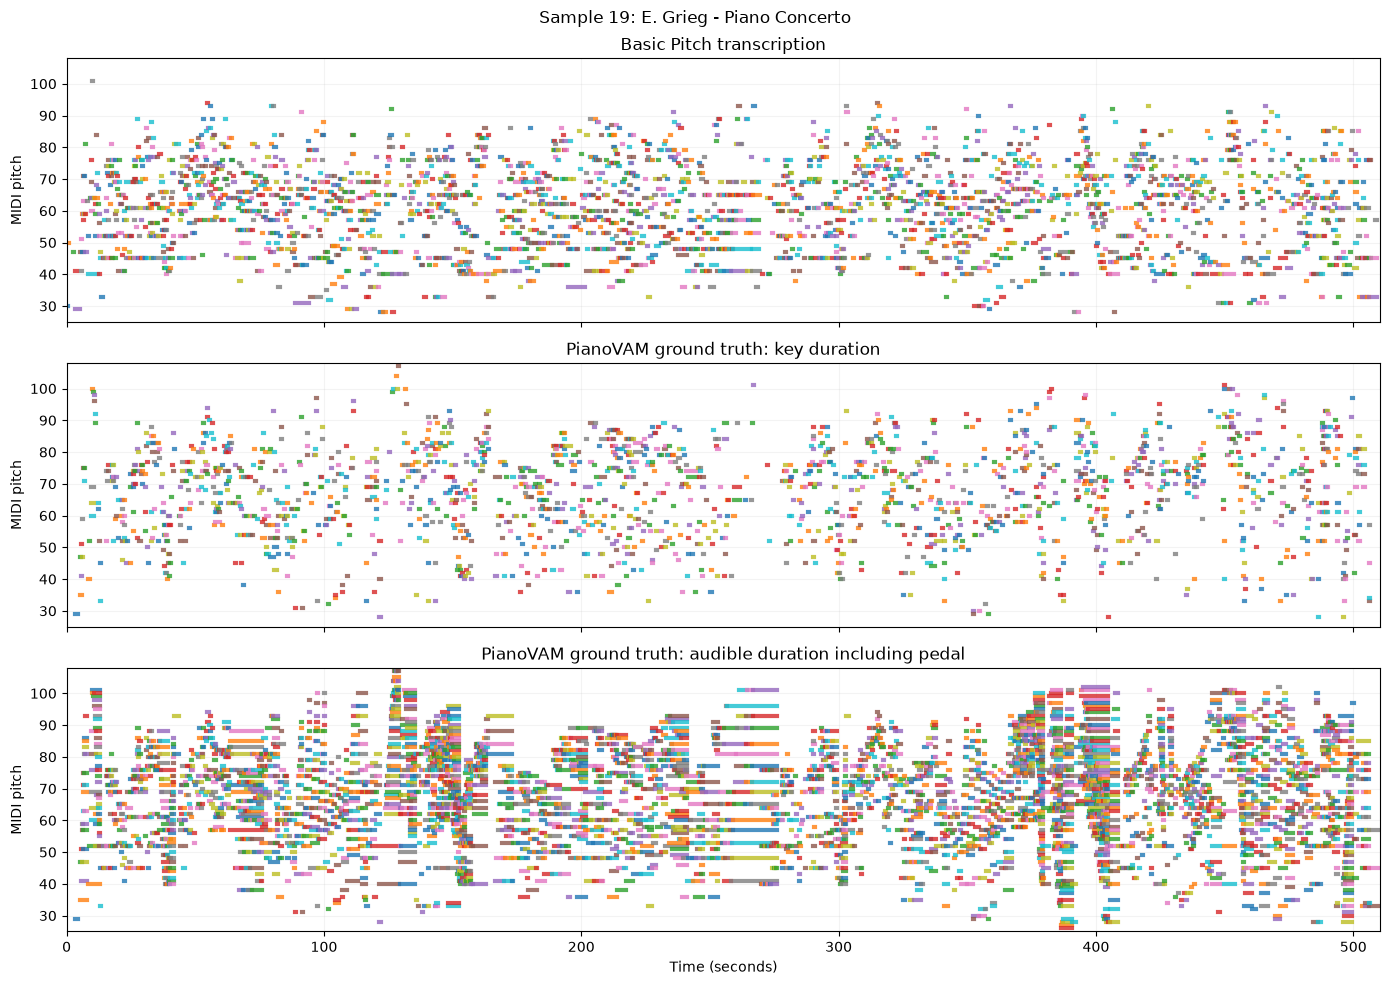

note_precision                        0.195482
note_recall                           0.124523
note_f1                               0.152135
note_precision_no_offset              0.753112
note_recall_no_offset                 0.479736
note_f1_no_offset                     0.586114
note_average_overlap_with_offset      0.892193
reference_notes                           6810
predicted_notes                           4338
note_count_difference                    -2472
transcription_missing_notes                571
transcription_extra_notes                   87
transcription_wrong_pitch_notes            346
transcription_wrong_timing_notes           634
transcription_wrong_duration_notes         609
transcription_missing_chords               284
transcription_extra_chords                  10
transcription_imperfect_chords            1078
transcription_wrong_chords                 104
transcription_output_is_correct          False
dtype: object

In [10]:
run_case_study(
    lowest_f1_sample_id,
    metadata_df,
    AUDIO_DIR,
    MIDI_DIR,
    TSV_DIR,
    RAW_PREDICTIONS_DIR,
    basic_pitch_model,
)

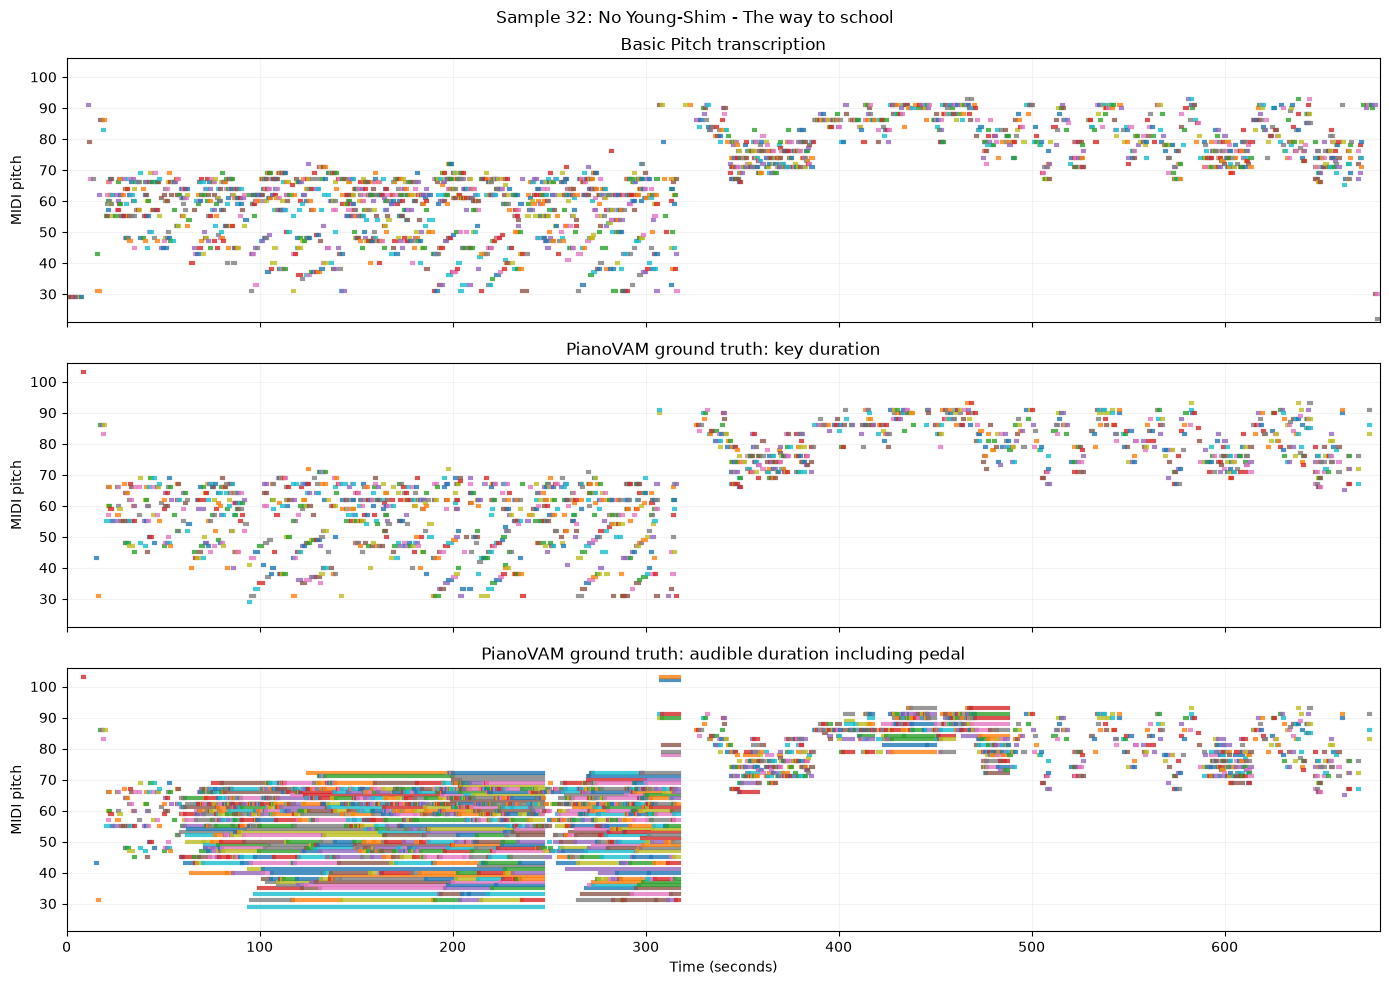

note_precision                        0.331661
note_recall                           0.309046
note_f1                               0.319954
note_precision_no_offset              0.887577
note_recall_no_offset                 0.827055
note_f1_no_offset                     0.856248
note_average_overlap_with_offset      0.939077
reference_notes                           3637
predicted_notes                           3389
note_count_difference                     -248
transcription_missing_notes                 66
transcription_extra_notes                   71
transcription_wrong_pitch_notes             79
transcription_wrong_timing_notes           348
transcription_wrong_duration_notes         776
transcription_missing_chords                21
transcription_extra_chords                   6
transcription_imperfect_chords             448
transcription_wrong_chords                   1
transcription_output_is_correct          False
dtype: object

In [11]:
run_case_study(
    highest_f1_sample_id,
    metadata_df,
    AUDIO_DIR,
    MIDI_DIR,
    TSV_DIR,
    RAW_PREDICTIONS_DIR,
    basic_pitch_model,
)

Overall, the pretrained Basic Pitch with default parameters successfully recovers most pitches and onsets. However, qualitative inspection of the piano-roll visualisations reveals several systematic transcription errors.

Firstly, duration seems to be one of the biggest source of errors. While most predicted notes begin at approximately the correct time, their offsets differ from the ground truth even though the frame-offset has already been used with the consideration of audible duration. This observation is also reflected in the large gap between the metrics with and without involving offset comparison.

Secondly, can observe from the pianoroll that the transcription contains some pre-performance non-musical sounds. Also, many sustained notes are fragmented into multiple short notes with identical pitches. This behaviour is particularly noticeable in pieces with extensive sustain pedal usage, where a single musical note is represented by several consecutive predictions instead of one continuous note. The extra notes often occurs in dense or harmonically complex regions.

Thirdly, by listening to some transcriptions, can find that they often sound more 'continuous' and 'noisy' than the ground truth, this may be due to pedal noise, some sympathetic resonance, piano overtones are recognized as independent notes.

Overall, these observations suggest that the pretrained model already provides reliable onset localisation but suffers from systematic post-processing limitations, particularly in duration estimation and note segmentation. Therefore, rather than starting to retrain the neural network right away, will focus on improving the transcription through implementing dedicated post-processing steps.

### To improve: post-processing experiments

In general, the Basic Pitch with default settings provides a strong baseline that can be adapted to this application (dataset with daily practice performance), try to further improve transcription quality through decoder calibration and task-specific post-processing. 

#### Decoder calibration, tune the thresholds

jointly tunes the four thresholds in the Basic Pitch decoder using the complete Solo training split, evaluated mainly based on median and mean note-level F1 without offset (`note_f1_no_offset`). This process was done on the validation set first with a wider grid to check whether it can improve or not, since the official split is designed carefully to support reproducibility and comparability, the splits will have similar characteristics and hence similar results. The param_grid here is narrowed according to the result of tuning on validation set.

In [12]:
# the best config on the validation set is 
# {'onset_threshold': 0.7, 'frame_threshold': 0.2, 'minimum_note_length': 75.0, 'melodia_trick': False}
# default config for Basic Pitch is: onset_threshold=0.5, frame_threshold=0.3
param_grid = {
    "onset_threshold": [0.5, 0.6, 0.7, 0.8],
    "frame_threshold": [0.1, 0.15, 0.2, 0.3],
    "minimum_note_length": [50, 75, 100, 150],
    "melodia_trick": [False],
}

parameter_sets = list(ParameterSampler(param_grid, n_iter=40, random_state=42))

In [13]:
# set to False to skip the random search
RUN_RANDOM_SEARCH = True

if RUN_RANDOM_SEARCH:
    basic_pitch_model = run_random_search(
        train_samples,
        parameter_sets,
        basic_pitch_model,
        AUDIO_DIR,
        MIDI_DIR,
        TSV_DIR,
        SEARCH_PROGRESS_PATH,
        ICASSP_2022_MODEL_PATH,
    )

random_search_results = summarise_random_search_results(SEARCH_PROGRESS_PATH)
random_search_results

Random search: 100%|██████████| 53/53 [1:49:48<00:00, 124.31s/it]  


,config_id,onset_threshold,frame_threshold,minimum_note_length,melodia_trick,note_precision_no_offset,note_recall_no_offset,note_f1_no_offset,note_f1_with_offset,predicted_notes
0,18,0.6,0.30,50,False,0.848710,0.754585,0.795786,0.239228,5830.018868
1,15,0.7,0.30,50,False,0.909930,0.682198,0.775713,0.232950,4911.773585
2,39,0.6,0.30,100,False,0.872970,0.702199,0.774564,0.236325,5262.962264
3,21,0.6,0.20,50,False,0.769867,0.782939,0.773516,0.261775,6655.924528
4,26,0.6,0.20,100,False,0.802609,0.751959,0.773477,0.264881,6140.716981
5,25,0.7,0.30,75,False,0.917976,0.670073,0.770562,0.232926,4780.811321
6,0,0.5,0.30,75,False,0.772857,0.773270,0.769865,0.224673,6572.773585
7,14,0.7,0.20,50,False,0.860299,0.698792,0.767303,0.259635,5309.773585
8,34,0.7,0.15,100,False,0.848311,0.689248,0.756918,0.278030,5314.283019
9,10,0.5,0.30,100,False,0.789472,0.731062,0.755239,0.222078,6069.037736


In [14]:
best_config = random_search_results.iloc[0]

TUNED_CONFIG = {
    "onset_threshold": float(best_config["onset_threshold"]),
    "frame_threshold": float(best_config["frame_threshold"]),
    "minimum_note_length": float(best_config["minimum_note_length"]),
    "melodia_trick": bool(best_config["melodia_trick"]),
}

train_tuned_df, tuned_predictions = evaluate_new_configuration_on_pianovam(
    TUNED_CONFIG, train_samples, AUDIO_DIR, MIDI_DIR, TSV_DIR, basic_pitch_model
)
TUNED_CONFIG

Evaluating configuration: 100%|██████████| 53/53 [11:41<00:00, 13.23s/it]


{'onset_threshold': 0.6,
 'frame_threshold': 0.3,
 'minimum_note_length': 50.0,
 'melodia_trick': False}

In [15]:
calibration_comparison = pd.DataFrame([
    comparison_row("Default Basic Pitch", train_baseline_df),
    comparison_row("Tuned Basic Pitch", train_tuned_df),
])

calibration_comparison

,configuration,mean_note_precision_no_offset,median_note_precision_no_offset,mean_note_recall_no_offset,median_note_recall_no_offset,mean_note_f1_no_offset,median_note_f1_no_offset,mean_note_f1_with_offset,mean_predicted_notes,mean_extra_notes,mean_missing_notes
0,Default Basic Pitch,0.711776,0.719745,0.712819,0.737346,0.706003,0.718216,0.207712,6532.150943,369.056604,425.622642
1,Tuned Basic Pitch,0.848710,0.857649,0.754585,0.758952,0.795786,0.800000,0.239228,5830.018868,26.169811,433.679245


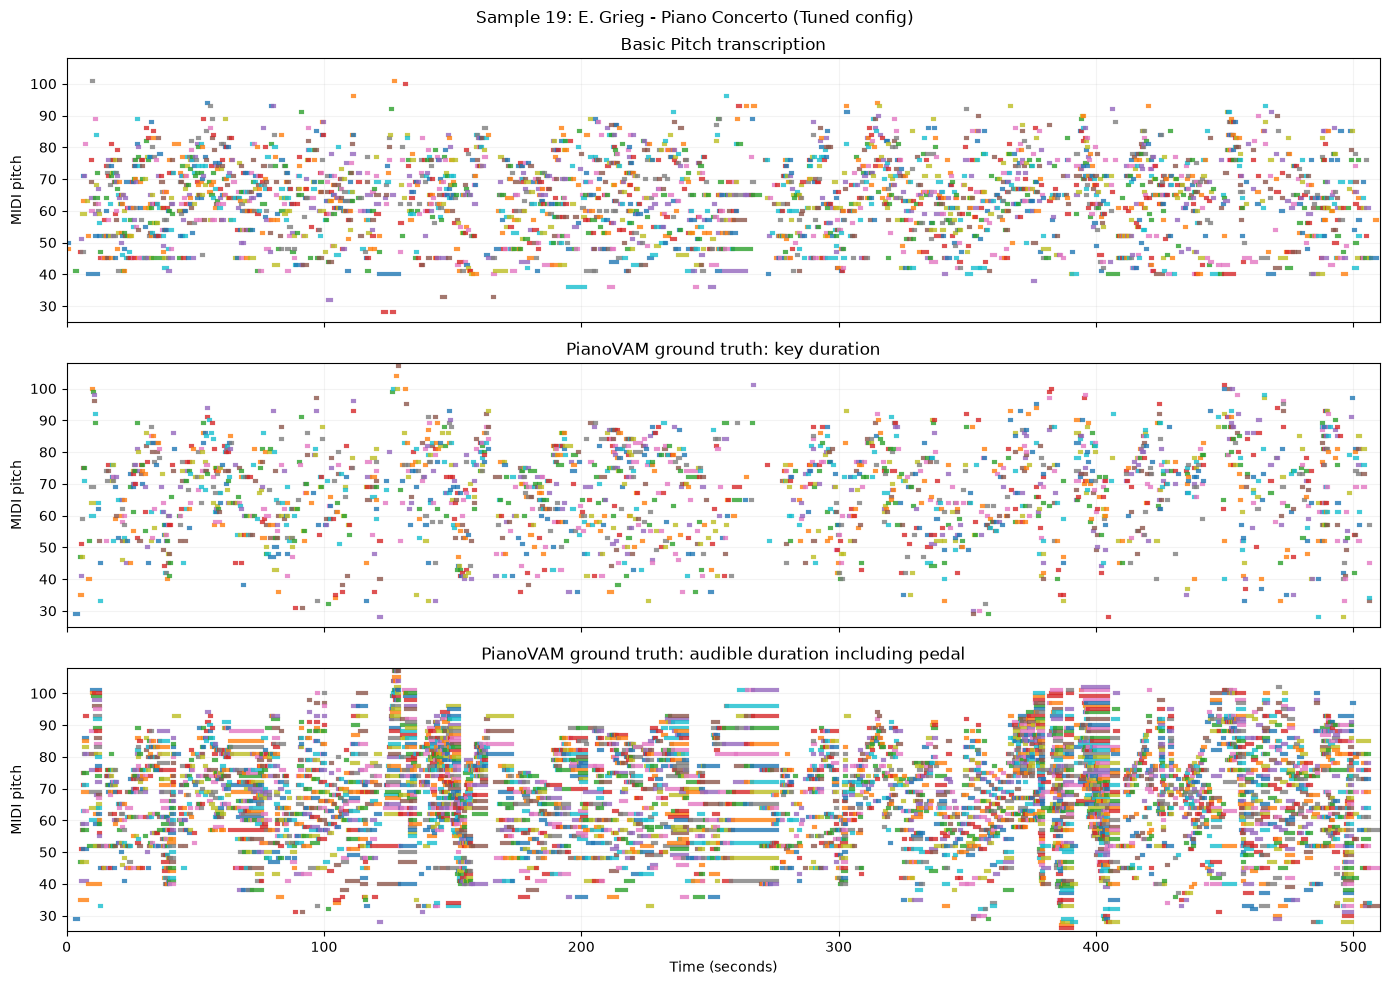

Sample 19


,note_precision,note_recall,note_f1,note_precision_no_offset,note_recall_no_offset,note_f1_no_offset,note_average_overlap_with_offset,reference_notes,predicted_notes,note_count_difference,transcription_missing_notes,transcription_extra_notes,transcription_wrong_pitch_notes,transcription_wrong_timing_notes,transcription_wrong_duration_notes,transcription_missing_chords,transcription_extra_chords,transcription_imperfect_chords,transcription_wrong_chords,transcription_output_is_correct
default,0.195482,0.124523,0.152135,0.753112,0.479736,0.586114,0.892193,6810.0,4338.0,-2472.0,571.0,87.0,346.0,634.0,609.0,284.0,10.0,1078.0,104.0,False
tuned,0.230166,0.150808,0.182221,0.867772,0.568576,0.687012,0.861933,6810.0,4462.0,-2348.0,501.0,10.0,219.0,398.0,591.0,308.0,4.0,1020.0,48.0,False
delta,0.034684,0.026285,0.030087,0.114660,0.088840,0.100898,-0.030260,0.0,124.0,124.0,-70.0,-77.0,-127.0,-236.0,-18.0,24.0,-6.0,-58.0,-56.0,NaN


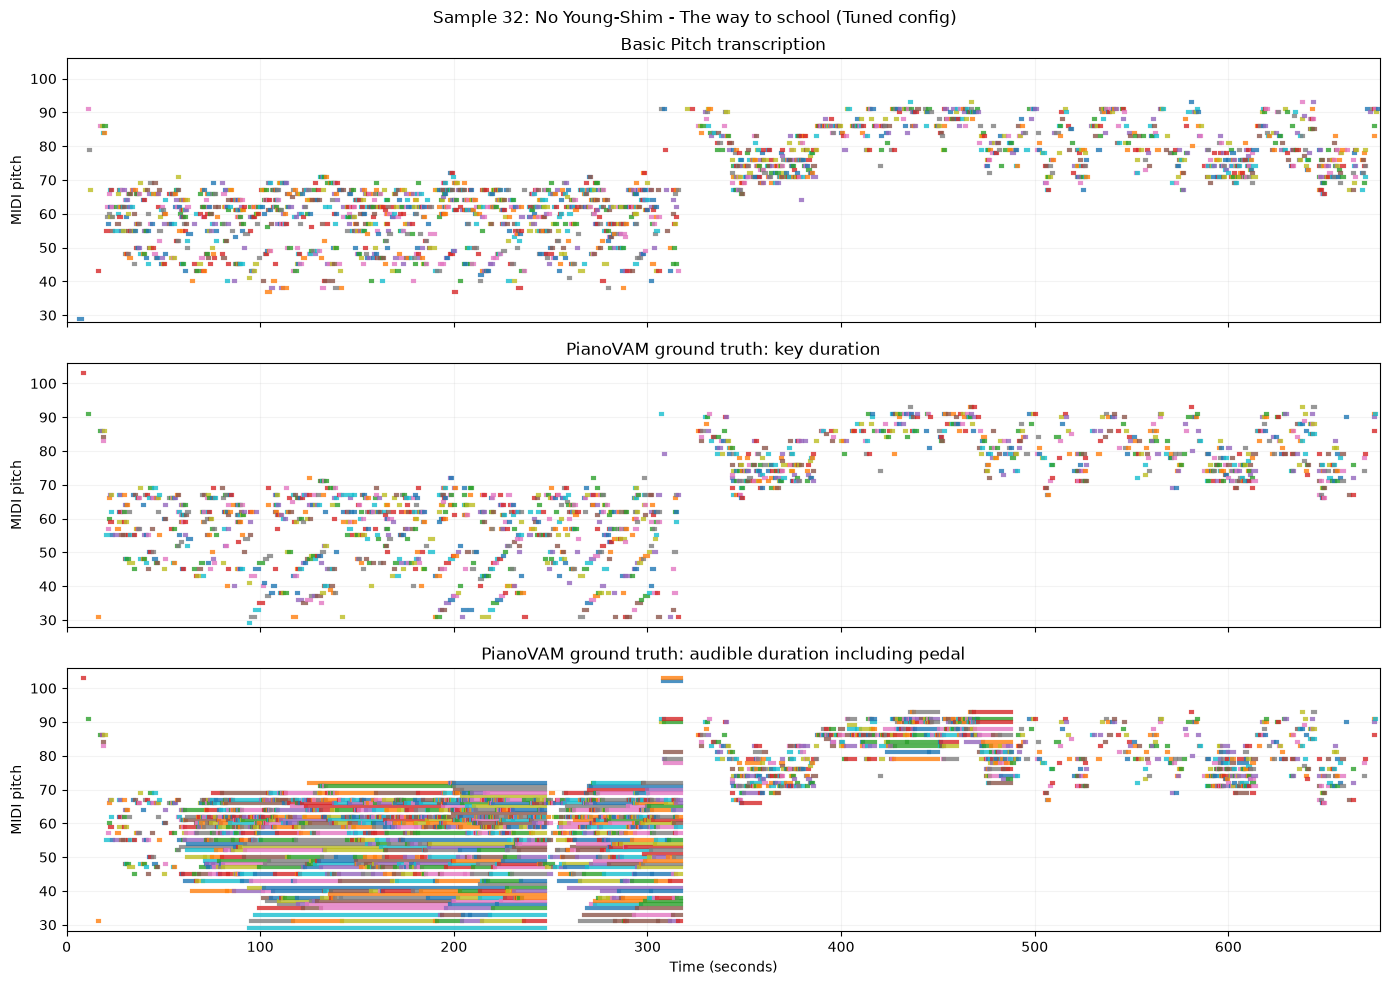

Sample 32


,note_precision,note_recall,note_f1,note_precision_no_offset,note_recall_no_offset,note_f1_no_offset,note_average_overlap_with_offset,reference_notes,predicted_notes,note_count_difference,transcription_missing_notes,transcription_extra_notes,transcription_wrong_pitch_notes,transcription_wrong_timing_notes,transcription_wrong_duration_notes,transcription_missing_chords,transcription_extra_chords,transcription_imperfect_chords,transcription_wrong_chords,transcription_output_is_correct
default,0.331661,0.309046,0.319954,0.887577,0.827055,0.856248,0.939077,3637.0,3389.0,-248.0,66.0,71.0,79.0,348.0,776.0,21.0,6.0,448.0,1.0,False
tuned,0.340883,0.331042,0.335891,0.928086,0.901292,0.914493,0.933260,3637.0,3532.0,-105.0,44.0,11.0,44.0,28.0,805.0,11.0,3.0,347.0,0.0,False
delta,0.009222,0.021996,0.015936,0.040509,0.074237,0.058245,-0.005816,0.0,143.0,143.0,-22.0,-60.0,-35.0,-320.0,29.0,-10.0,-3.0,-101.0,-1.0,NaN


In [16]:
for case_study_sample_id in ["19", "32"]:
    comparison_df = run_case_study_before_after_tuning(
        case_study_sample_id,
        metadata_df,
        AUDIO_DIR,
        MIDI_DIR,
        TSV_DIR,
        RAW_PREDICTIONS_DIR,
        TUNED_PREDICTIONS_DIR,
        TUNED_CONFIG,
        basic_pitch_model,
    )
    print("Sample", case_study_sample_id)
    display(comparison_df)

#### Error analysis (FP and FN analysis)

In [17]:
fp_fn_summary_df = summarise_fp_fn_over_train_set(
    train_samples, metadata_df, AUDIO_DIR, MIDI_DIR, TSV_DIR, tuned_predictions
)

fp_fn_summary_df["fragment_only_rate"] = fp_fn_summary_df["fragment_only"] / fp_fn_summary_df["total_extra"]
fp_fn_summary_df["harmonic_interval_only_rate"] = fp_fn_summary_df["harmonic_interval_only"] / fp_fn_summary_df["total_extra"]
fp_fn_summary_df["both_patterns_rate"] = fp_fn_summary_df["both_patterns"] / fp_fn_summary_df["total_extra"]
fp_fn_summary_df["neither_pattern_rate"] = fp_fn_summary_df["neither_pattern"] / fp_fn_summary_df["total_extra"]
fp_fn_summary_df["extra_at_beginning_rate"] = fp_fn_summary_df["extra_at_beginning"] / fp_fn_summary_df["total_extra"]
fp_fn_summary_df["dense_region_extra_rate"] = fp_fn_summary_df["dense_region_extra"] / fp_fn_summary_df["total_extra"]

fp_fn_summary_df["short_missing_rate"] = fp_fn_summary_df["short_missing"] / fp_fn_summary_df["total_missing"]
fp_fn_summary_df["repeated_pitch_missing_rate"] = fp_fn_summary_df["repeated_pitch_missing"] / fp_fn_summary_df["total_missing"]
fp_fn_summary_df["chord_related_missing_rate"] = fp_fn_summary_df["chord_related_missing"] / fp_fn_summary_df["total_missing"]

display(fp_fn_summary_df)

print("Overall FP breakdown:")
print("  fragment_only:", fp_fn_summary_df["fragment_only"].sum() / fp_fn_summary_df["total_extra"].sum())
print("  harmonic_interval_only:", fp_fn_summary_df["harmonic_interval_only"].sum() / fp_fn_summary_df["total_extra"].sum())
print("  both_patterns:", fp_fn_summary_df["both_patterns"].sum() / fp_fn_summary_df["total_extra"].sum())
print("  neither_pattern:", fp_fn_summary_df["neither_pattern"].sum() / fp_fn_summary_df["total_extra"].sum())
print("  extra_at_beginning:", fp_fn_summary_df["extra_at_beginning"].sum() / fp_fn_summary_df["total_extra"].sum())
print("  dense_region_extra:", fp_fn_summary_df["dense_region_extra"].sum() / fp_fn_summary_df["total_extra"].sum())

print("Overall FN breakdown:")
print("  short_missing:", fp_fn_summary_df["short_missing"].sum() / fp_fn_summary_df["total_missing"].sum())
print("  repeated_pitch_missing:", fp_fn_summary_df["repeated_pitch_missing"].sum() / fp_fn_summary_df["total_missing"].sum())
print("  chord_related_missing:", fp_fn_summary_df["chord_related_missing"].sum() / fp_fn_summary_df["total_missing"].sum())

FP/FN summary: 100%|██████████| 53/53 [02:41<00:00,  3.04s/it]


,sample_id,total_predicted_notes,total_reference_notes,total_extra,total_missing,fragment_only,harmonic_interval_only,both_patterns,neither_pattern,short_extra,...,chord_related_missing,fragment_only_rate,harmonic_interval_only_rate,both_patterns_rate,neither_pattern_rate,extra_at_beginning_rate,dense_region_extra_rate,short_missing_rate,repeated_pitch_missing_rate,chord_related_missing_rate
0,0,5119,6935,579,2395,33,276,227,43,122,...,1976,0.056995,0.476684,0.392055,0.074266,0.003454,0.561313,0.083090,0.001253,0.825052
1,1,4740,5281,612,1153,30,336,192,54,177,...,966,0.049020,0.549020,0.313725,0.088235,0.000000,0.717320,0.387684,0.000000,0.837814
2,4,6921,8117,942,2138,84,457,349,52,177,...,1473,0.089172,0.485138,0.370488,0.055202,0.002123,0.579618,0.023854,0.000000,0.688962
3,5,5093,5755,997,1659,113,374,400,110,147,...,776,0.113340,0.375125,0.401204,0.110331,0.004012,0.251755,0.056058,0.001206,0.467752
4,6,20648,28084,2468,9904,142,1126,1085,115,425,...,8263,0.057536,0.456240,0.439627,0.046596,0.000000,0.679498,0.078453,0.001313,0.834309
5,7,6537,7376,826,1665,49,423,272,82,100,...,1094,0.059322,0.512107,0.329298,0.099274,0.000000,0.600484,0.014414,0.000000,0.657057
6,10,3733,5316,482,2065,33,206,204,39,101,...,1591,0.068465,0.427386,0.423237,0.080913,0.000000,0.655602,0.107506,0.001453,0.770460
7,13,1400,1795,303,698,40,108,120,35,50,...,218,0.132013,0.356436,0.396040,0.115512,0.013201,0.092409,0.017192,0.007163,0.312321
8,14,6418,8759,990,3331,98,436,340,116,185,...,2516,0.098990,0.440404,0.343434,0.117172,0.012121,0.597980,0.055839,0.000600,0.755329
9,15,5997,8106,995,3104,114,409,359,113,170,...,2400,0.114573,0.411055,0.360804,0.113568,0.005025,0.539698,0.064433,0.001933,0.773196


Overall FP breakdown:
  fragment_only: 0.07285342584562012
  harmonic_interval_only: 0.5029243667578447
  both_patterns: 0.3373585073498343
  neither_pattern: 0.08686370004670091
  extra_at_beginning: 0.0018235594991882936
  dense_region_extra: 0.5541397024484622
Overall FN breakdown:
  short_missing: 0.08452703292864006
  repeated_pitch_missing: 0.0015721897108917809
  chord_related_missing: 0.7581884880775613


After decoder calibration, the remaining transcription errors were primarily associated with polyphonic regions:

FP:
- Approximately 55.4% occurred in the dense region with multiple ref notes.
- A small number (about 0.18%) of extra notes occurred before the first reference onset, suggesting that pre-performance sounds may be transcribed as notes.
There are extra notes at the beginning, which would probably be non-musical event
- Although 84.0% of the extra notes overlapped with a matched prediction at a fifth- or octave-related interval, these intervals are also common in valid piano chords, so it is tricky to distinguish whether it is designed to be polyphonic or acoustic harmonic errors. 
- Fragment-like predictions account for approximately 41% in total, consider merging then in the targeted post-processing part.

FN:
- 75.8% are chord related as they occurred in near-simultaneous note regions. However, recovering missing chord or imperfect chords from note-event output alone would require guessing pitches that are not confidently produced by the AMT model, this was therefore treated as a limitation of the transcription model.

Generally speaking, the largest FP patterns are associated with harmonic overlap and dense polyphonic regions. Most FNs occur as missing members of chords. These errors are difficult to remove safely without deleting correct notes.

#### Targeted post-processing steps
- remove a limited number of isolated leading predictions before the main performance start;
- merge short same-pitch fragments separated by or overlapped with a very small gap, i.e. when their timing suggests they are actually one continuous note.

In [18]:
train_postprocessed_df, postprocessed_predictions = evaluate_postprocessing(
    postprocess_predictions,
    train_samples,
    AUDIO_DIR,
    MIDI_DIR,
    TSV_DIR,
    tuned_predictions,
)

postprocessing_comparison = pd.DataFrame([
    comparison_row("Tuned Basic Pitch", train_tuned_df),
    comparison_row(
        "Tuned + targeted post-processing",
        train_postprocessed_df,
    ),
])

postprocessing_comparison

Post-processing evaluation: 100%|██████████| 53/53 [08:14<00:00,  9.34s/it]


,configuration,mean_note_precision_no_offset,median_note_precision_no_offset,mean_note_recall_no_offset,median_note_recall_no_offset,mean_note_f1_no_offset,median_note_f1_no_offset,mean_note_f1_with_offset,mean_predicted_notes,mean_extra_notes,mean_missing_notes
0,Tuned Basic Pitch,0.848710,0.857649,0.754585,0.758952,0.795786,0.800000,0.239228,5830.018868,26.169811,433.679245
1,Tuned + targeted post-processing,0.850076,0.858274,0.751392,0.758952,0.794579,0.799899,0.237554,5796.886792,25.452830,441.830189


Overall, the targeted post-processing successfully reduced the number of predicted notes and produced a small improvement in precision, indicating that some false-positive predictions were removed. However, there is an increase in missing notes, leading to a slight reduction in recall and a slight decrease in the overall F1 score. 

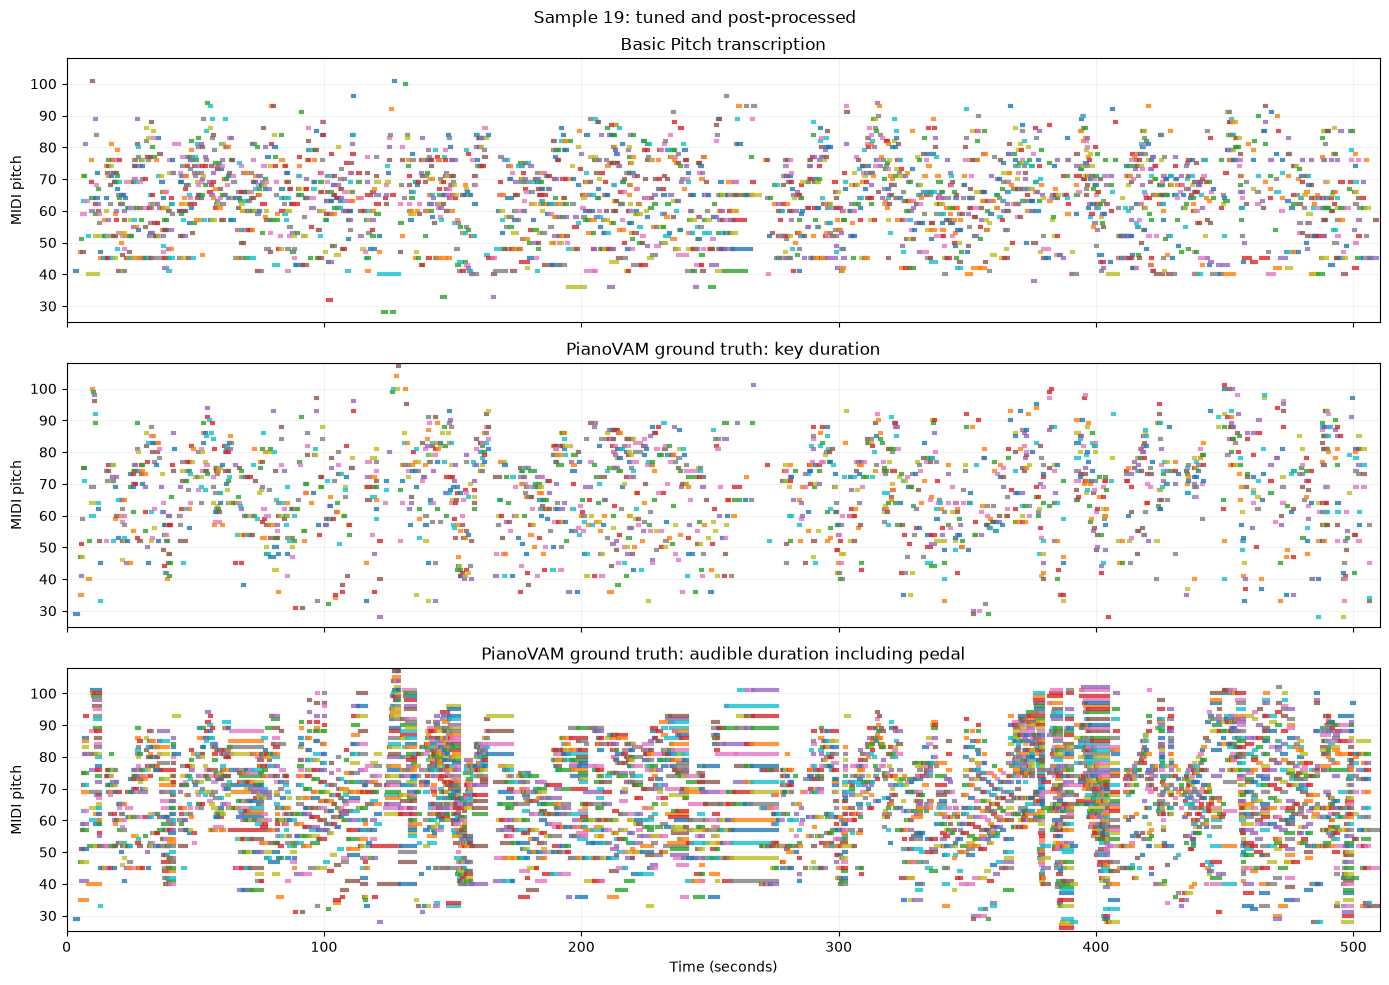

In [19]:
sample_id = lowest_f1_sample_id
sample = metadata_df[metadata_df["sample_id"] == sample_id].iloc[0]
paths = get_sample_paths(sample, AUDIO_DIR, MIDI_DIR, TSV_DIR)
reference_notes = load_ground_truth_notes(paths["tsv"])

plot_transcription_piano_roll(
    reference_notes,
    postprocessed_predictions[sample_id],
    title=f"Sample {sample_id}: tuned and post-processed",
)

### Evaluation on test set

In [20]:
# Run this after the decoder configuration and post-processing rules are fixed.
test_baseline_df = evaluate_on_pianovam(
    "test", metadata_df,
    AUDIO_DIR, 
    MIDI_DIR, 
    TSV_DIR, 
    RAW_PREDICTIONS_DIR,
    basic_pitch_model,
)

test_tuned_df, test_tuned_predictions = evaluate_new_configuration_on_pianovam(
    TUNED_CONFIG,
    test_samples,
    AUDIO_DIR,
    MIDI_DIR,
    TSV_DIR,
    basic_pitch_model,
)

test_postprocessed_df, test_postprocessed_predictions = evaluate_postprocessing(
    postprocess_predictions,
    test_samples,
    AUDIO_DIR,
    MIDI_DIR,
    TSV_DIR,
    test_tuned_predictions,
)

test_comparison = pd.DataFrame([
    comparison_row("Default Basic Pitch", test_baseline_df),          
    comparison_row("Tuned Basic Pitch", test_tuned_df),
    comparison_row("Tuned + targeted post-processing", test_postprocessed_df),
])

test_comparison

Post-processing evaluation: 100%|██████████| 9/9 [00:38<00:00,  4.33s/it]


,configuration,mean_note_precision_no_offset,median_note_precision_no_offset,mean_note_recall_no_offset,median_note_recall_no_offset,mean_note_f1_no_offset,median_note_f1_no_offset,mean_note_f1_with_offset,mean_predicted_notes,mean_extra_notes,mean_missing_notes
0,Default Basic Pitch,0.699004,0.661520,0.775779,0.751523,0.725641,0.740562,0.238708,4793.222222,229.222222,158.888889
1,Tuned Basic Pitch,0.813910,0.823995,0.832767,0.886282,0.817995,0.815534,0.274124,4581.555556,29.444444,156.444444
2,Tuned + targeted post-processing,0.816607,0.824828,0.829040,0.871698,0.817358,0.815204,0.271278,4546.555556,28.111111,171.333333


Overall, the increase in precision and slight decrease in recall is consistent with the result of train set, which showed that many remaining transcription errors are associated with dense polyphonic passages and missing chord notes. These errors cannot be reliably corrected using simple rule-based post-processing without removing correct notes.

### Visualize the transcription quality using a simple case

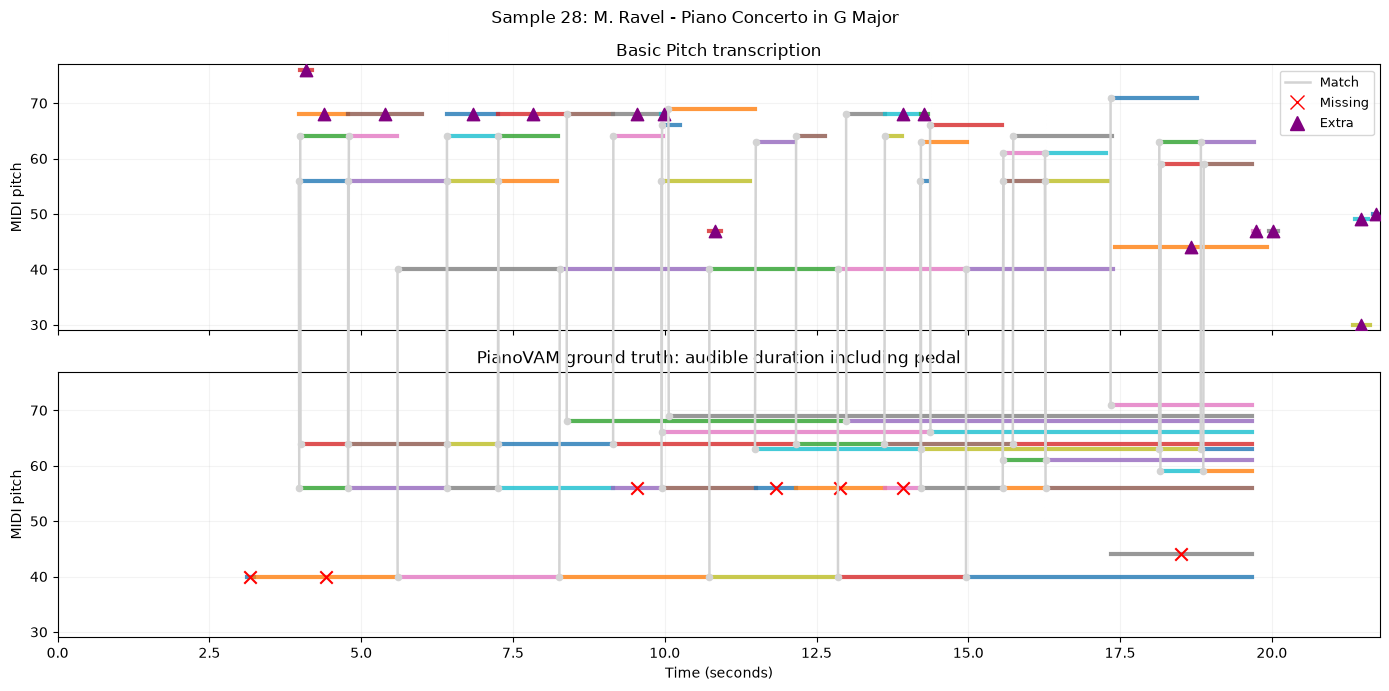

{'matched': 35, 'missing': 7, 'extra': 16}

In [25]:
sample_id = "28"
sample = metadata_df[metadata_df["sample_id"].astype(str) == sample_id].iloc[0]

paths = get_sample_paths(sample, AUDIO_DIR, MIDI_DIR, TSV_DIR)

reference_notes = load_ground_truth_notes(paths["tsv"])

if sample_id in tuned_predictions:
    predicted_notes = tuned_predictions[sample_id]
else:
    predicted_notes, _, _ = transcribe_audio(
        paths["audio"],
        basic_pitch_model,
        **TUNED_CONFIG,
    )

predicted_notes = postprocess_predictions(predicted_notes)

alignment_summary = plot_transcription_alignment(
    reference_notes,
    predicted_notes,
    title="Sample 28: M. Ravel - Piano Concerto in G Major",
    offset_ratio=None,
)

alignment_summary

Obeserved from the plot above, most note pairs are matched, indicating that the transcription captures most of the principal melodic and harmonic notes. The remaining errors are dominated by extra notes rather than missing notes. By listening to the transcripted MIDI, the 'missing notes' at the begining are actually not missing, but quieter than other notes. The other missing notes appears to be part of chords. The extra notes at the end appears to be non-musical sound while the other are caused by acoustic harmonic reverberation and pedal usage. 

## Conclusion and Limitation

Phase 2 extends the original MIDI evaluation feedback pipeline to accept audio as input by integrating a pretrained AMT model called Basic Pitch, and the transcription quality is improved by decoder calibration using the PianoVAM dataset which is closer to education and practice senario. Error analysis further reveals that most remaining transcription errors are associated with harmonic effects, pedal usage, dense polyphonic regions, non-musical events, and weak notes which sounds quieter.

Limitations:
- Although decoder calibration improves the baseline transcription, the proposed rule-based post-processing still needs more careful design and experiment. To reduce the effect of transcription error on the precision of feedback generation, can consider introducing a `levels of confidence` metric to better distinguish reliable and unreliable predictions before generating feedback, i.e. feedback message about certain error will not be generated if this error may be due to transcription error.
- The evaluation is based on the PianoVAM dataset, whose recordings are relatively clean and consistently recorded. The performance of the pipeline on self-recorded practice audio, which may contain more background noise, different acoustic conditions, different level of performance, all remains to be investigated. If there is larger dataset containing audio file and corresponding ground truth MIDI in the music practice senario, can consider train a model from scratch, or retrain and fine-tune the existing model.

#### regenerate plots for the report

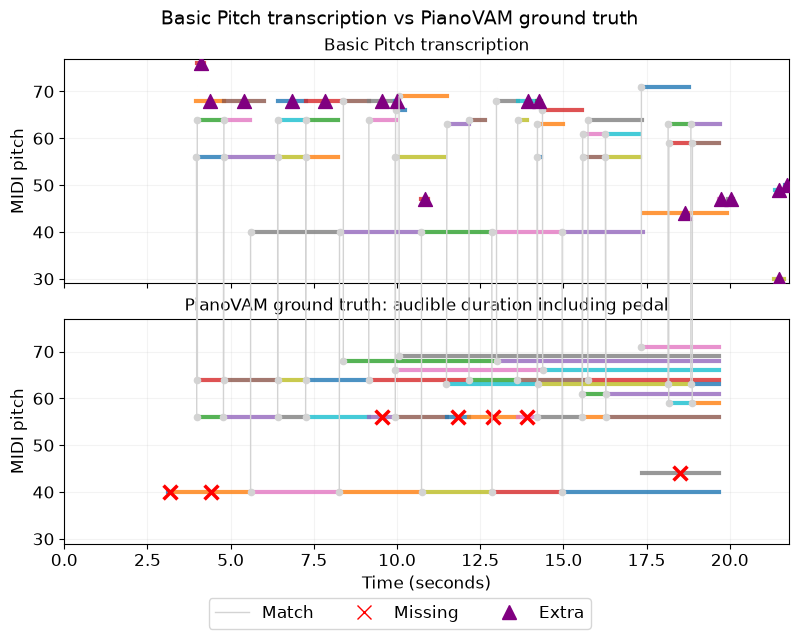

matched: 35, missing: 7, extra: 16


In [32]:
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import ConnectionPatch
from notebooks.utils.transcription_evaluation import match_notes_for_plotting

# ------------------------------------------------------------------------------
# Parameters -- edit these directly and re-run this cell
# ------------------------------------------------------------------------------
title = "Basic Pitch transcription vs PianoVAM ground truth"
onset_tolerance = 0.05
offset_ratio = None  # None gives onset-and-pitch matching, consistent with note_f1_no_offset
time_range = None    # e.g. (10.0, 20.0) to zoom into a specific window, or None for the full clip

figure_width_cm = 20   # slightly wider too, since the data spans ~20 seconds
figure_height_cm = 16  # taller, to fit two subplot titles + suptitle + legend
font_size = 12

# reference_notes and predicted_notes are assumed to already exist in the
# notebook (e.g. loaded from a PianoVAM sample and its Basic Pitch output)

# ------------------------------------------------------------------------------
# Match notes and set up the figure
# ------------------------------------------------------------------------------
matching, missing_indices, extra_indices = match_notes_for_plotting(
    reference_notes,
    predicted_notes,
    onset_tolerance=onset_tolerance,
    offset_ratio=offset_ratio,
)

cm_to_inch = 1 / 2.54
figure_size = (figure_width_cm * cm_to_inch, figure_height_cm * cm_to_inch)

fig, (ax_predicted, ax_reference) = plt.subplots(
    2, 1,
    figsize=figure_size,
    sharex=True,
    constrained_layout=True,
)

if title is not None:
    fig.suptitle(title, fontsize=font_size + 2)

all_pitches = (
    [note["pitch"] for note in predicted_notes]
    + [note["pitch"] for note in reference_notes]
)

all_offsets = (
    [note["offset"] for note in predicted_notes]
    + [note["frame_offset"] for note in reference_notes]
)

pitch_min = min(all_pitches) - 1
pitch_max = max(all_pitches) + 1
time_max = max(all_offsets)

# ------------------------------------------------------------------------------
# Draw every note as a horizontal line
# ------------------------------------------------------------------------------
for note in predicted_notes:
    ax_predicted.plot(
        [note["onset"], note["offset"]],
        [note["pitch"], note["pitch"]],
        linewidth=3,
        alpha=0.8,
    )

for note in reference_notes:
    ax_reference.plot(
        [note["onset"], note["frame_offset"]],
        [note["pitch"], note["pitch"]],
        linewidth=3,
        alpha=0.8,
    )


def note_is_visible(note, offset_key):
    if time_range is None:
        return True

    return (
        note[offset_key] >= time_range[0]
        and note["onset"] <= time_range[1]
    )


# ------------------------------------------------------------------------------
# Draw connectors for matched pairs, and markers for missing/extra notes
# ------------------------------------------------------------------------------
for reference_index, predicted_index in matching:
    reference_note = reference_notes[reference_index]
    predicted_note = predicted_notes[predicted_index]

    pair_is_visible = (
        note_is_visible(reference_note, "frame_offset")
        or note_is_visible(predicted_note, "offset")
    )

    if pair_is_visible:
        connection = ConnectionPatch(
            xyA=(predicted_note["onset"], predicted_note["pitch"]),
            coordsA=ax_predicted.transData,
            xyB=(reference_note["onset"], reference_note["pitch"]),
            coordsB=ax_reference.transData,
            color="lightgray",
            linewidth=1.0,
            zorder=10,
        )

        fig.add_artist(connection)

        ax_predicted.scatter(
            predicted_note["onset"],
            predicted_note["pitch"],
            color="lightgray",
            s=20,
            zorder=10,
        )

        ax_reference.scatter(
            reference_note["onset"],
            reference_note["pitch"],
            color="lightgray",
            s=20,
            zorder=10,
        )

for reference_index in missing_indices:
    note = reference_notes[reference_index]

    if note_is_visible(note, "frame_offset"):
        middle_time = note["onset"] + (note["frame_offset"] - note["onset"]) / 2
        ax_reference.scatter(middle_time, note["pitch"], marker="x",
                             color="red", s=100, zorder=10, linewidths=2.5)

for predicted_index in extra_indices:
    note = predicted_notes[predicted_index]

    if note_is_visible(note, "offset"):
        middle_time = note["onset"] + (note["offset"] - note["onset"]) / 2
        ax_predicted.scatter(middle_time, note["pitch"], marker="^",
                             color="purple", s=100, zorder=10)

# ------------------------------------------------------------------------------
# Titles, labels, axis limits, legend
# ------------------------------------------------------------------------------
ax_predicted.set_title("Basic Pitch transcription", fontsize=font_size)
ax_predicted.set_ylabel("MIDI pitch", fontsize=font_size)
ax_predicted.grid(alpha=0.15)
ax_predicted.tick_params(axis="both", labelsize=font_size)

ax_reference.set_title("PianoVAM ground truth: audible duration including pedal", fontsize=font_size)
ax_reference.set_xlabel("Time (seconds)", fontsize=font_size)
ax_reference.set_ylabel("MIDI pitch", fontsize=font_size)
ax_reference.grid(alpha=0.15)
ax_reference.tick_params(axis="both", labelsize=font_size)

if time_range is None:
    x_min = 0
    x_max = time_max
else:
    x_min, x_max = time_range

for ax in (ax_predicted, ax_reference):
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(pitch_min, pitch_max)

legend_elements = [
    Line2D([0], [0], color="lightgray", linewidth=1.0, label="Match"),
    Line2D([0], [0], marker="x", color="white", markeredgecolor="red",
           markersize=10, label="Missing"),
    Line2D([0], [0], marker="^", color="white", markerfacecolor="purple",
           markeredgecolor="purple", markersize=10, label="Extra"),
]

fig.legend(handles=legend_elements, loc="outside lower center", ncol=3, fontsize=font_size)

plt.show()

print(f"matched: {len(matching)}, missing: {len(missing_indices)}, extra: {len(extra_indices)}")